# Projeto de análise exploratória dos dados PNAD-C do IBGE  
## Notebook Jupyter

**Tema do TCC:** *Diversidade, Inclusão e Equidade nas Organizações Brasileiras: preparação para a força de trabalho futura sob a lente da interseccionalidade*  
**Contexto acadêmico:** apoio ao TCC de Daniele Silva da Cruz Nagem (PUC-RS)

---

## Apresentação

Este notebook traduz o script de análise exploratória `eda.py` para um formato simplificado, mantendo a lógica original do pipeline e reorganizando a execução em etapas mais adequadas à leitura, documentação metodológica e apresentação de resultados.

A proposta do projeto, é reunir dados, scripts e análises do TCC com foco em desigualdades de sexo e raça/cor no mercado de trabalho brasileiro, usando a PNAD Contínua como base empírica principal. Destacando que a análise busca apoiar os argumentos do trabalho com evidência quantitativa, priorizando metodologia transparente, uso de dados oficiais e estrutura modular por hipóteses.

## Objetivo analítico

Investigar, com base em dados oficiais da PNAD Contínua, como desigualdades interseccionais se manifestam em diferentes dimensões do mercado de trabalho brasileiro, especialmente em:

- renda;
- escolaridade;
- estrutura ocupacional;
- formalização;
- inserção ocupacional;
- juventude;
- acesso a cargos de liderança.

## Hipóteses investigadas

As sete hipóteses abaixo seguem a estrutura do artigo cientifico proposto assim foi implementada no script original tentando responder as seguintes perguntas.

- **H1:** A educação aumenta a renda para todos os grupos da mesma forma, ou a desigualdade persiste mesmo em níveis mais altos de escolaridade?
- **H2:** O retorno da escolaridade é igual entre os grupos, ou se torna mais desigual nos níveis mais altos?
- **H3:** Diferentes grupos estão distribuídos de forma semelhante entre as ocupações, ou existe segregação ocupacional?
- **H4:** O aumento da escolaridade leva à formalização do trabalho de forma igual para todos os grupos, ou a desigualdade permanece?
- **H5:** As diferenças de renda entre grupos são explicadas pelo tipo de ocupação, ou persistem mesmo dentro das mesmas ocupações?
- **H6:** Os jovens de hoje ainda enfrentam as mesmas desigualdades do passado?
- **H7:** O acesso a cargos de liderança é distribuído de forma proporcional entre os grupos, ou existe concentração em grupos específicos?

## Como este notebook está organizado

1. Configuração do ambiente e definição de parâmetros.
2. Funções utilitárias e de visualização.
3. Preparação e padronização da base analítica.
4. Execução modular das hipóteses H1–H7.
5. Geração de tabelas, figuras e relatório textual.
6. Espaço para leitura acadêmica e interpretação dos achados.

## Metodologia resumida

O projeto foi estruturado em duas grandes etapas: construção da base analítica e análise exploratória com teste de hipóteses. A base foi consolidada a partir da PNAD Contínua, com padronização entre anos, aplicação de deflator para renda real e criação de variáveis analíticas como o grupo interseccional, escolaridade, ocupação e setor. Na etapa de EDA, o projeto utiliza leitura otimizada da base consolidada, pesos amostrais do IBGE em todos os cálculos e geração automatizada de tabelas, gráficos e relatório textual.

Neste notebook, essa mesma lógica é mantida. Em termos práticos, isso significa:

- uso de **médias e proporções ponderadas** por peso amostral;
- recorte principal entre **18 e 65 anos**;
- preservação das categorias analíticas do script original;
- separação entre **base analítica real** e **ajustes visuais** (winsorização para gráficos);
- execução modular por hipótese, permitindo rastreabilidade metodológica.

## Configuração do projeto

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from typing import Iterable
from decimal import Decimal, getcontext

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("[OK] Configuração do projeto carregada")

[OK] Configuração do projeto carregada


## Argumentos e parâmetros de execução

No script original, a execução foi concebida para linha de comando com `argparse`. Nesse notebook, isso continua útil porque permite manter coerência com o pipeline principal, mas também foi definido uma configuração manual para facilitar a execução célula a célula.

In [4]:
DATA_URL = "https://media.githubusercontent.com/media/daninagem/tccpuc/refs/heads/main/dataset/pnadc_ocupados_2015_2025_base.csv.gz"

VALUE_COL = "renda_habitual_real"
WEIGHT_COL = "peso"

IDADE_MIN = 18
IDADE_MAX = 65

SHOW_PLOTS = True

WINSORIZE = True
WINSORIZE_Q = 0.99

print("[OK] Parâmetros definidos com sucesso")

[OK] Parâmetros definidos com sucesso


## Funções utilitárias

In [5]:
def print_block(code: str, desc: str | None = None, pergunta: str | None = None) -> None:
    title = code if desc is None else f"{code} — {desc}"
    print("\n" + "=" * 100)
    print(title)
    if pergunta:
        print(pergunta)
    print("=" * 100)


def fmt_money(x: float) -> str:
    if pd.isna(x):
        return "NA"
    s = f"{x:,.2f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")


def fit_linear_trend(x, y) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    a, b = np.polyfit(x[mask], y[mask], 1)
    return float(a), float(b)


def wmean(x: pd.Series, w: pd.Series) -> float:
    getcontext().prec = 28

    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")

    mask = x.notna() & w.notna() & (w > 0)
    if not mask.any():
        return np.nan

    x_vals = x[mask].astype("float64").values
    w_vals = w[mask].astype("float64").values

    num = Decimal(0)
    den = Decimal(0)

    for xi, wi in zip(x_vals, w_vals):
        num += Decimal(str(xi)) * Decimal(str(wi))
        den += Decimal(str(wi))

    return float(num / den)

## Funções de visualização

Os gráficos abaixo seguem a mesma lógica do script principal: séries temporais com tendência linear, gráficos de barras empilhadas, heatmaps tabulares e rankings por barras. Esse conjunto foi pensado para transformar medidas ponderadas em saídas visuais consistentes para leitura analítica e acadêmica.

In [6]:
def plot_bar_rank(
    s,
    title,
    show=True,
    ylabel="Valor",
    fmt="{:.1f}"
):
    if s is None or len(s) == 0:
        print(f"[WARN] {title}: série vazia.")
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(s.index.astype(str), s.values)

    for i, v in enumerate(s.values):
        if not np.isnan(v) and v != 0:
            ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=8)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.3)

    show_or_close(fig, show)

def show_or_close(fig, show: bool) -> None:
    if show:
        plt.show()
    else:
        plt.close(fig)


def styled_line(ax, x, y, label: str) -> None:
    GROUP_COLORS = {
        "Homens Brancos": "#1f77b4",
        "Homens Pretos/Pardos": "#ff7f0e",
        "Mulheres Brancas": "#2ca02c",
        "Mulheres Pretas/Pardas": "#d62728",
    }
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2.3,
        label=str(label),
        color=GROUP_COLORS.get(str(label)),
    )


def add_bar_labels(ax, fmt="{:.1f}", rotation=0, fontsize=8) -> None:
    for container in ax.containers:
        labels = []
        for bar in container:
            h = bar.get_height()
            labels.append("" if np.isnan(h) or h == 0 else fmt.format(h))
        ax.bar_label(container, labels=labels, padding=2, rotation=rotation, fontsize=fontsize)


def plot_series_por_grupo_com_tendencia(
    tab_ano_grupo: pd.DataFrame,
    title: str,
    y_label: str = "Valor",
    show: bool = True,
) -> None:
    if tab_ano_grupo.empty:
        return

    dfp = tab_ano_grupo.copy().sort_index()
    anos = dfp.index.to_numpy(dtype=float)

    fig, ax = plt.subplots()

    for col in dfp.columns:
        y = dfp[col].to_numpy(dtype=float)
        styled_line(ax, anos, y, col)
        a, b = fit_linear_trend(anos, y)
        if not np.isnan(a):
            ax.plot(anos, a * anos + b, linestyle="--", linewidth=1.5)

    ax.set_title(title)
    ax.set_xlabel("Ano")
    ax.set_ylabel(y_label)
    ax.legend(loc="best")

    show_or_close(fig, show)


def plot_stacked_bar(
    piv: pd.DataFrame,
    title: str,
    ylabel: str = "Participação (%)",
    show: bool = True,
) -> None:
    if piv.empty:
        return

    fig, ax = plt.subplots()

    bottom = np.zeros(len(piv.index))
    x = np.arange(len(piv.index))

    for c in piv.columns:
        vals = piv[c].fillna(0).to_numpy()
        ax.bar(x, vals, bottom=bottom, label=c)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(piv.index.tolist(), rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100)
    ax.legend(ncols=2)

    show_or_close(fig, show)


def plot_heatmap_like(
    piv: pd.DataFrame,
    title: str,
    cmap: str = "PuBuGn",
    fmt: str = ".1f",
    show: bool = True,
) -> None:
    if piv.empty:
        return

    fig, ax = plt.subplots()

    data = piv.to_numpy(dtype=float)
    im = ax.imshow(data, aspect="auto", cmap=cmap)

    ax.set_xticks(np.arange(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=25, ha="right")

    ax.set_yticks(np.arange(len(piv.index)))
    ax.set_yticklabels(piv.index)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isfinite(data[i, j]):
                ax.text(j, i, f"{data[i, j]:{fmt}}", ha="center", va="center", fontsize=8)

    ax.set_title(title)

    fig.colorbar(im, ax=ax, shrink=0.85)

    show_or_close(fig, show)


## Preparação da base analítica

Esta etapa concentra a padronização de variáveis, criação de colunas derivadas e aplicação dos filtros centrais do estudo. É aqui que a base é transformada em um insumo comparável entre anos e grupos.

O processo contempla padronização de schema, tratamento de aliases entre anos e criação de variáveis analíticas como o grupo interseccional e categorias de escolaridade e ocupação.

In [7]:
GROUP_ORDER = [
    "Homens Brancos",
    "Homens Pretos/Pardos",
    "Mulheres Brancas",
    "Mulheres Pretas/Pardas",
]

SCHOOL_ORDER = [
    "Sem instrução/Fundamental incompleto",
    "Fundamental completo",
    "Médio incompleto",
    "Médio completo",
    "Superior incompleto",
    "Superior completo",
    "Pós-graduação (ou equivalente)",
]

REGIAO_ORDER = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]


def add_missing_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    d = df

    if "sexo_desc" not in d.columns and "sexo_label" in d.columns:
        d["sexo_desc"] = d["sexo_label"]

    if "raca_cor_analitica" not in d.columns and "raca_cor_label" in d.columns:
        d["raca_cor_analitica"] = np.where(
            d["raca_cor_label"].isin(["Preta", "Parda"]),
            "Pretos/Pardos",
            np.where(d["raca_cor_label"].eq("Branca"), "Branca", None),
        )

    if "grupo_h1" not in d.columns and {"sexo_desc", "raca_cor_analitica"}.issubset(d.columns):
        d["grupo_h1"] = np.select(
            [
                (d["sexo_desc"] == "Mulher") & (d["raca_cor_analitica"] == "Pretos/Pardos"),
                (d["sexo_desc"] == "Homem") & (d["raca_cor_analitica"] == "Branca"),
                (d["sexo_desc"] == "Mulher") & (d["raca_cor_analitica"] == "Branca"),
                (d["sexo_desc"] == "Homem") & (d["raca_cor_analitica"] == "Pretos/Pardos"),
            ],
            [
                "Mulheres Pretas/Pardas",
                "Homens Brancos",
                "Mulheres Brancas",
                "Homens Pretos/Pardos",
            ],
            default=None,
        )

    if "regiao_desc" not in d.columns and "uf_sigla" in d.columns:
        reg_map = {
            "RO": "Norte", "AC": "Norte", "AM": "Norte", "RR": "Norte", "PA": "Norte", "AP": "Norte", "TO": "Norte",
            "MA": "Nordeste", "PI": "Nordeste", "CE": "Nordeste", "RN": "Nordeste", "PB": "Nordeste", "PE": "Nordeste",
            "AL": "Nordeste", "SE": "Nordeste", "BA": "Nordeste",
            "MG": "Sudeste", "ES": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
            "PR": "Sul", "SC": "Sul", "RS": "Sul",
            "MS": "Centro-Oeste", "MT": "Centro-Oeste", "GO": "Centro-Oeste", "DF": "Centro-Oeste",
        }
        d["regiao_desc"] = d["uf_sigla"].map(reg_map)

    return d


def prepare_base(
    df: pd.DataFrame,
    value_col: str,
    weight_col: str,
    idade_min: int,
    idade_max: int,
) -> pd.DataFrame:

    d = add_missing_derived_columns(df)

    needed = [
        "ano", "idade", weight_col, value_col,
        "sexo_desc", "raca_cor_analitica", "escolaridade_desc", "grupo_h1",
    ]

    missing = [c for c in needed if c not in d.columns]
    if missing:
        raise ValueError(f"Colunas ausentes: {missing}")

    for c in ["ano", "idade", weight_col, value_col]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    mask = (
        d[weight_col].notna()
        & (d[weight_col] > 0)
        & d["idade"].notna()
        & d["idade"].between(idade_min, idade_max, inclusive="both")
        & d["grupo_h1"].notna()
    )

    d = d.loc[mask].copy()

    d["escolaridade_desc"] = pd.Categorical(
        d["escolaridade_desc"].astype("string"),
        categories=SCHOOL_ORDER,
        ordered=True,
    )

    return d

## Carregamento da base consolidada

In [8]:
print("=" * 80)
print("BASE — Carregando base consolidada")
print("=" * 80)

df_raw = pd.read_csv(
    DATA_URL,
    compression="gzip",
    low_memory=False,
    dtype_backend="pyarrow"
)

print(f"[INFO] Linhas: {len(df_raw):,}")
print(f"[INFO] Colunas: {len(df_raw.columns)}")

BASE — Carregando base consolidada
[INFO] Linhas: 8,596,751
[INFO] Colunas: 16


## Perfil inicial da base

A célula abaixo fornece uma inspeção rápida da estrutura de dados usada ao longo do notebook. Esse passo é útil, pois facilita a documentação do universo observacional, da tipagem das variáveis e da coerência do recorte analítico.

In [9]:
print("\n[INFO] Colunas disponíveis:")
print(df_raw.columns.tolist())

print("\n[INFO] Tipos das variáveis:")
display(df_raw.dtypes)

print("\n[INFO] Primeiras linhas:")
display(df_raw.head())

print("\n[INFO] Percentual de valores nulos (top 20):")
display((df_raw.isna().mean() * 100).sort_values(ascending=False).head(20))
cols_necessarias = ["ano", "idade", WEIGHT_COL, VALUE_COL]

print("\n[CHECK] Validação de colunas essenciais:")
for col in cols_necessarias:
    if col in df_raw.columns:
        print(f"[OK] {col}")
    else:
        print(f"[ERRO] {col} NÃO encontrada")


[INFO] Colunas disponíveis:
['ano', 'idade', 'peso', 'renda_habitual_real', 'sexo_desc', 'raca_cor_analitica', 'escolaridade_desc', 'grupo_h1', 'ocup_h3', 'atividade_h5', 'posicao_ocupacao_desc', 'formal_ampliado', 'categoria_trabalho', 'carteira_assinada', 'cbo_detalhe_label', 'uf_sigla']

[INFO] Tipos das variáveis:


,0
ano,int64[pyarrow]
idade,int64[pyarrow]
peso,double[pyarrow]
renda_habitual_real,double[pyarrow]
sexo_desc,string[pyarrow]
raca_cor_analitica,string[pyarrow]
escolaridade_desc,string[pyarrow]
grupo_h1,string[pyarrow]
ocup_h3,string[pyarrow]
atividade_h5,string[pyarrow]



[INFO] Primeiras linhas:


,ano,idade,peso,renda_habitual_real,sexo_desc,raca_cor_analitica,escolaridade_desc,grupo_h1,ocup_h3,atividade_h5,posicao_ocupacao_desc,formal_ampliado,categoria_trabalho,carteira_assinada,cbo_detalhe_label,uf_sigla
0,2015,21,27.885513,1395.1294,Mulher,Pretos/Pardos,Médio completo,Mulheres Pretas/Pardas,4. Trabalhadores de apoio administrativo,4. Comércio e reparação de veículos,Privado com carteira,True,1,1,Recepcionistas em geral,AC
1,2015,19,30.020042,1281.8193,Mulher,Pretos/Pardos,Fundamental completo,Mulheres Pretas/Pardas,4. Trabalhadores de apoio administrativo,"7. Informação, finanças, imobiliárias, profiss...",Privado com carteira,True,1,1,Escriturários gerais,AC
2,2015,31,31.0569,5311.4062,Mulher,Pretos/Pardos,Superior completo,Mulheres Pretas/Pardas,4. Trabalhadores de apoio administrativo,"7. Informação, finanças, imobiliárias, profiss...",Privado com carteira,True,1,1,Secretários (geral),AC
3,2015,35,31.587814,1395.1294,Mulher,Pretos/Pardos,Médio completo,Mulheres Pretas/Pardas,9. Ocupações elementares,"8. Administração pública, educação, saúde e se...",Privado com carteira,True,1,1,Trabalhadores de limpeza de interior de edifíc...,AC
4,2015,22,31.430418,1395.1294,Mulher,Pretos/Pardos,Médio completo,Mulheres Pretas/Pardas,"5. Serviços, vendedores dos comércios e mercados",4. Comércio e reparação de veículos,Privado com carteira,True,1,1,Balconistas e vendedores de lojas,AC



[INFO] Percentual de valores nulos (top 20):


,0
carteira_assinada,43.233798
renda_habitual_real,2.992305
cbo_detalhe_label,0.012365
ano,0.000000
sexo_desc,0.000000
raca_cor_analitica,0.000000
idade,0.000000
peso,0.000000
grupo_h1,0.000000
escolaridade_desc,0.000000



[CHECK] Validação de colunas essenciais:
[OK] ano
[OK] idade
[OK] peso
[OK] renda_habitual_real


## Preparar a base para insights

In [10]:
df = prepare_base(
    df_raw,
    value_col=VALUE_COL,
    weight_col=WEIGHT_COL,
    idade_min=IDADE_MIN,
    idade_max=IDADE_MAX
)

print(f"[INFO] Linhas após preparação: {len(df):,}")
df_plot = df

if WINSORIZE and VALUE_COL in df.columns:
    cap = df[VALUE_COL].quantile(WINSORIZE_Q)
    df_plot = df.copy()
    df_plot[VALUE_COL] = np.minimum(df_plot[VALUE_COL], cap)

    print(f"[INFO] Winsorização aplicada em q={WINSORIZE_Q}: teto = {fmt_money(cap)}")

[INFO] Linhas após preparação: 8,596,751
[INFO] Winsorização aplicada em q=0.99: teto = 19.000,00


## H1 — Renda por escolaridade

Nesta hipótese, o foco é verificar se o aumento da escolaridade produz ganhos de renda semelhantes entre os grupos analisados ou se as desigualdades persistem mesmo quando todos avançam educacionalmente.

🔢 Renda média ponderada (R$) por escolaridade × grupo

In [11]:
tab_h1 = (
    df_plot
    .groupby(["escolaridade_desc", "grupo_h1"], observed=False)[[VALUE_COL, WEIGHT_COL]]
    .apply(lambda g: wmean(g[VALUE_COL], g[WEIGHT_COL]))
    .reset_index(name="renda_media")
)

piv_h1 = tab_h1.pivot(index="escolaridade_desc", columns="grupo_h1", values="renda_media")

piv_h1 = piv_h1.reindex(SCHOOL_ORDER)
piv_h1 = piv_h1[[c for c in GROUP_ORDER if c in piv_h1.columns]]

display(piv_h1.round(2))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
escolaridade_desc,,,,
Sem instrução/Fundamental incompleto,2278.88,1692.51,1510.14,1172.96
Fundamental completo,2697.70,2103.48,1771.74,1439.17
Médio incompleto,2545.30,1966.86,1730.72,1379.53
Médio completo,3153.84,2483.77,2145.00,1719.28
Superior incompleto,3809.31,3130.19,2447.34,2026.63
Superior completo,6879.95,5217.22,4722.50,3549.83
Pós-graduação (ou equivalente),10368.90,8156.13,7140.35,5277.88


📊 Heatmap

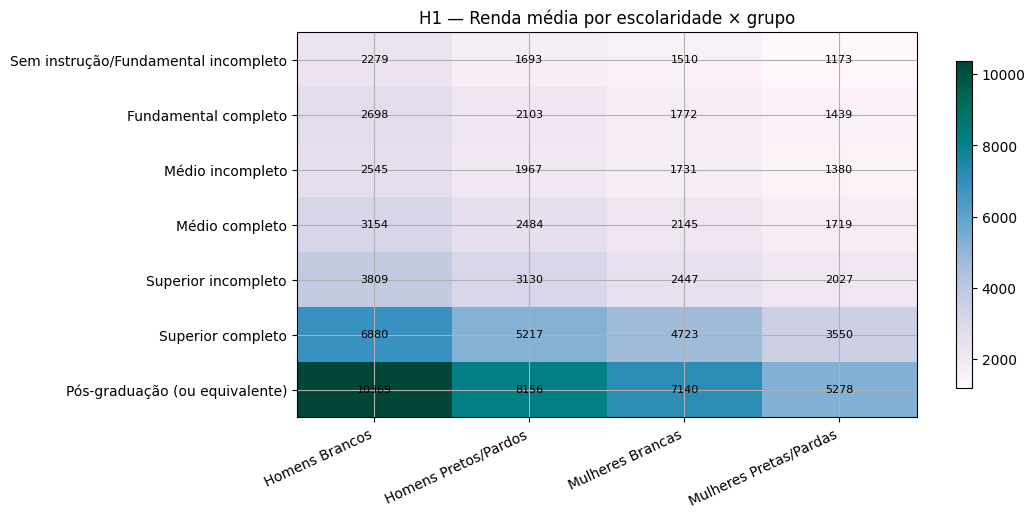

In [12]:
plot_heatmap_like(
    piv_h1,
    title="H1 — Renda média por escolaridade × grupo",
    cmap="PuBuGn",
    fmt=".0f",
    show=SHOW_PLOTS
)

📉 Gap relativo (%) Mulheres Pretas/Pardas vs Homens Brancos por escolaridade

In [13]:
if {"Homens Brancos", "Mulheres Pretas/Pardas"}.issubset(piv_h1.columns):
    gap_h1 = ((piv_h1["Mulheres Pretas/Pardas"] / piv_h1["Homens Brancos"]) - 1) * 100
    display(gap_h1.round(1))

,0
escolaridade_desc,
Sem instrução/Fundamental incompleto,-48.5
Fundamental completo,-46.7
Médio incompleto,-45.8
Médio completo,-45.5
Superior incompleto,-46.8
Superior completo,-48.4
Pós-graduação (ou equivalente),-49.1


📈 Evolução temporal

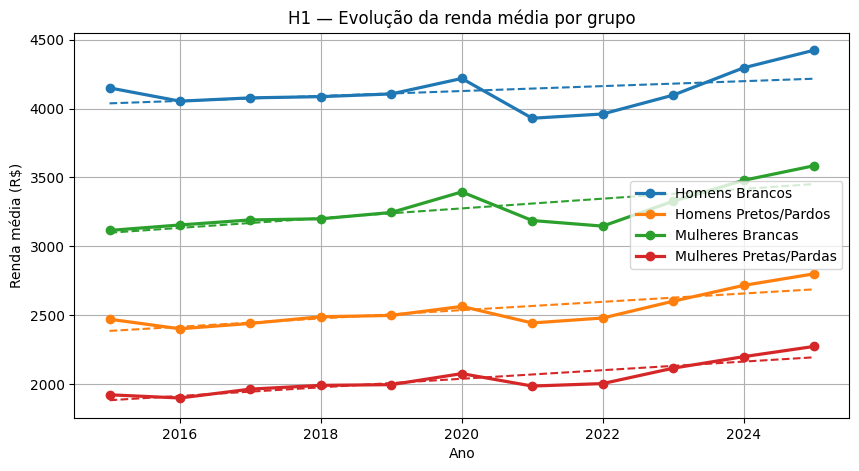

In [14]:
tab_ano = (
    df_plot
    .groupby(["ano", "grupo_h1"], observed=False)[[VALUE_COL, WEIGHT_COL]]
    .apply(lambda g: wmean(g[VALUE_COL], g[WEIGHT_COL]))
    .reset_index(name="renda_media")
)

piv_ano = tab_ano.pivot(index="ano", columns="grupo_h1", values="renda_media")
piv_ano = piv_ano[[c for c in GROUP_ORDER if c in piv_ano.columns]]

plot_series_por_grupo_com_tendencia(
    piv_ano,
    title="H1 — Evolução da renda média por grupo",
    y_label="Renda média (R$)",
    show=SHOW_PLOTS
)

📈 Evolução anual do gap (%) Mulheres Pretas/Pardas vs Homens Brancos

,0
ano,
2015,-53.64
2016,-53.11
2017,-51.81
2018,-51.25
2019,-51.36
2020,-50.75
2021,-49.43
2022,-49.38
2023,-48.34


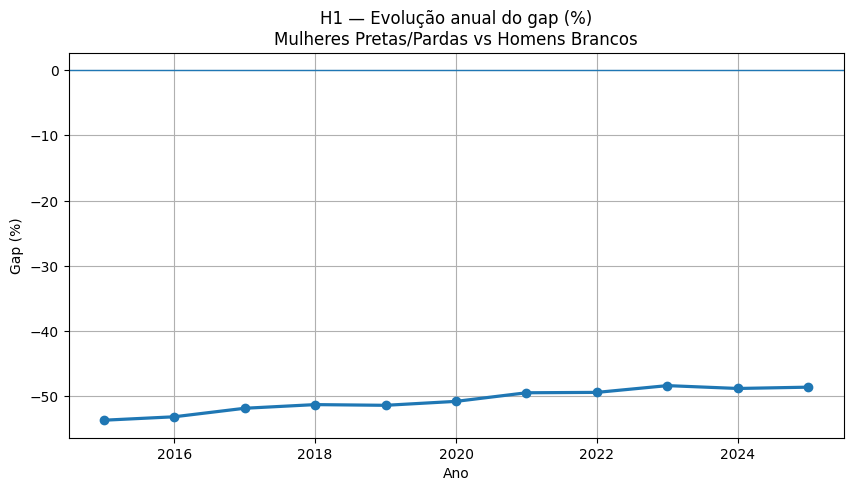

In [15]:
if {"Mulheres Pretas/Pardas", "Homens Brancos"}.issubset(piv_ano.columns):
    gap_ano_h1 = ((piv_ano["Mulheres Pretas/Pardas"] / piv_ano["Homens Brancos"]) - 1) * 100

    display(gap_ano_h1.round(2))

    fig, ax = plt.subplots()

    ax.plot(
        gap_ano_h1.index.astype(int),
        gap_ano_h1.values,
        marker="o",
        linewidth=2.3
    )

    ax.axhline(0, linewidth=1)
    ax.set_title("H1 — Evolução anual do gap (%)\nMulheres Pretas/Pardas vs Homens Brancos")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Gap (%)")

    show_or_close(fig, SHOW_PLOTS)

## H2 — Retorno da escolaridade

Aqui, o objetivo não é apenas observar a renda em cada nível educacional, mas medir o retorno marginal da escolaridade entre etapas sucessivas, buscando identificar se os ganhos relativos se distribuem de forma desigual.

🔢 Retorno marginal entre níveis consecutivos de escolaridade (%)

In [16]:
returns_h2 = piv_h1.pct_change(axis=0) * 100

returns_h2 = returns_h2.drop(index=[
    "Sem instrução/Fundamental incompleto",
    "Médio incompleto"
], errors="ignore")

display(returns_h2.round(1))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
escolaridade_desc,,,,
Fundamental completo,18.4,24.3,17.3,22.7
Médio completo,23.9,26.3,23.9,24.6
Superior incompleto,20.8,26.0,14.1,17.9
Superior completo,80.6,66.7,93.0,75.2
Pós-graduação (ou equivalente),50.7,56.3,51.2,48.7


📊 Heatmap

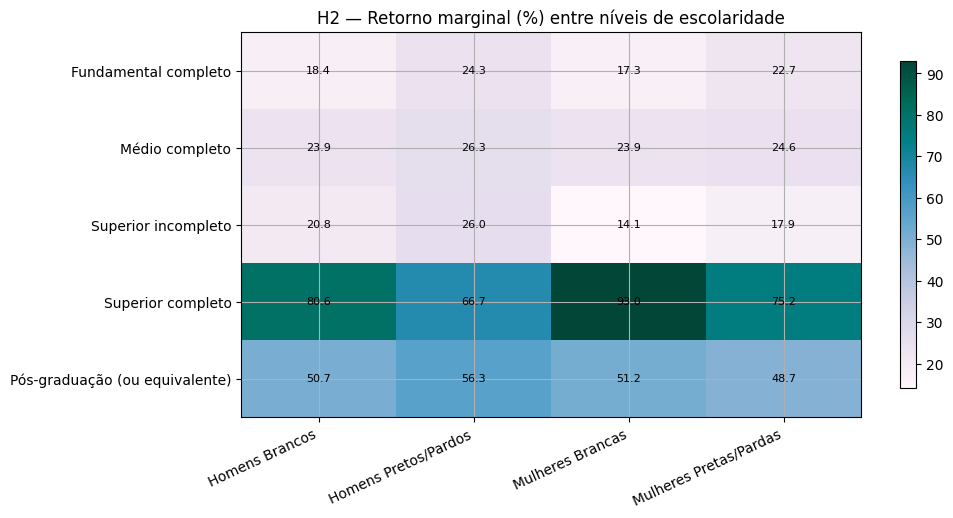

In [17]:
plot_heatmap_like(
    returns_h2,
    title="H2 — Retorno marginal (%) entre níveis de escolaridade",
    cmap="PuBuGn",
    fmt=".1f",
    show=SHOW_PLOTS
)

📊 Gráfico

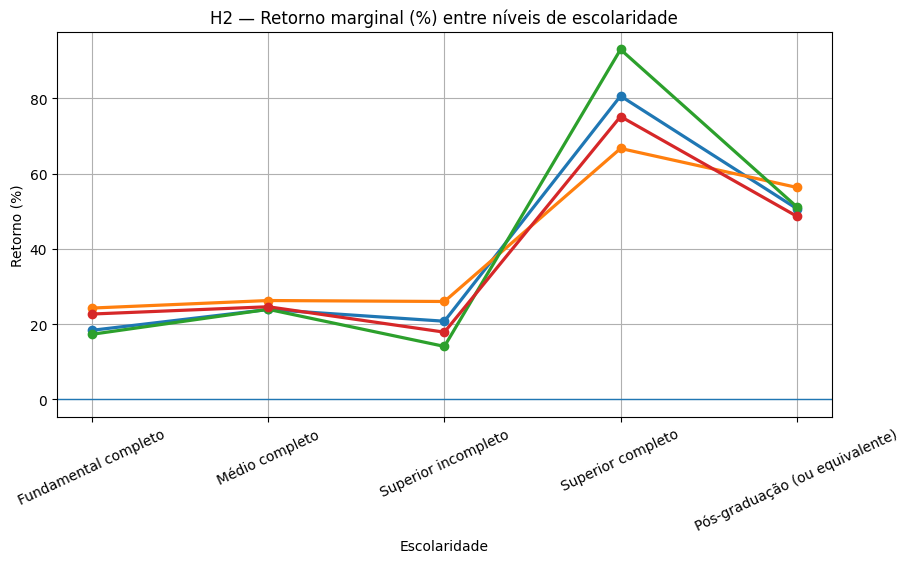

In [18]:
fig, ax = plt.subplots()

x = returns_h2.index.astype(str)

for col in returns_h2.columns:
    styled_line(ax, x, returns_h2[col].values, col)

ax.axhline(0, linewidth=1)
ax.set_title("H2 — Retorno marginal (%) entre níveis de escolaridade")
ax.set_xlabel("Escolaridade")
ax.set_ylabel("Retorno (%)")
ax.tick_params(axis="x", rotation=25)

show_or_close(fig, SHOW_PLOTS)

## H3 — Estrutura ocupacional

Esta parte examina se os grupos estão distribuídos de maneira semelhante entre as grandes ocupações ou se existe segregação ocupacional, inclusive entre os mais escolarizados.

🔢 Distribuição ocupacional ponderada (%) por grupo

In [19]:
H3_ORDER = [
    "1. Diretores e gerentes",
    "2. Profissionais das ciências e intelectuais",
    "3. Técnicos e profissionais de nível médio",
    "4. Trabalhadores de apoio administrativo",
    "5. Serviços, vendedores dos comércios e mercados",
    "6. Agropecuária, florestais, caça e pesca",
    "7. Construção, artes mecânicas e outros ofícios",
    "8. Operadores de instalações e máquinas",
    "9. Ocupações elementares",
    "10. Forças armadas, policiais e bombeiros militares",
    "11. Ocupações mal definidas",
]

tab_h3 = (
    df
    .groupby(["grupo_h1", "ocup_h3"], observed=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="peso")
)

total_h3 = (
    tab_h3
    .groupby("grupo_h1")["peso"]
    .sum()
    .reset_index(name="total")
)

tab_h3 = tab_h3.merge(total_h3, on="grupo_h1")
tab_h3["pct"] = (tab_h3["peso"] / tab_h3["total"]) * 100

piv_h3 = tab_h3.pivot(index="grupo_h1", columns="ocup_h3", values="pct").fillna(0)

piv_h3 = piv_h3.reindex(GROUP_ORDER)
piv_h3 = piv_h3[[c for c in H3_ORDER if c in piv_h3.columns]]

display(piv_h3.round(2))

ocup_h3,1. Diretores e gerentes,2. Profissionais das ciências e intelectuais,3. Técnicos e profissionais de nível médio,4. Trabalhadores de apoio administrativo,"5. Serviços, vendedores dos comércios e mercados","6. Agropecuária, florestais, caça e pesca","7. Construção, artes mecânicas e outros ofícios",8. Operadores de instalações e máquinas,9. Ocupações elementares,"10. Forças armadas, policiais e bombeiros militares",11. Ocupações mal definidas
grupo_h1,,,,,,,,,,,
Homens Brancos,6.73,12.34,10.17,6.01,15.96,7.01,17.72,12.9,9.74,1.41,0.02
Homens Pretos/Pardos,2.55,5.04,6.79,5.18,16.95,7.96,21.55,13.88,18.56,1.53,0.02
Mulheres Brancas,5.41,21.45,9.87,12.99,25.84,2.59,4.88,2.77,13.94,0.23,0.01
Mulheres Pretas/Pardas,2.28,11.79,7.74,10.88,31.98,2.52,5.13,2.71,24.77,0.18,0.01


📊 Gráfico

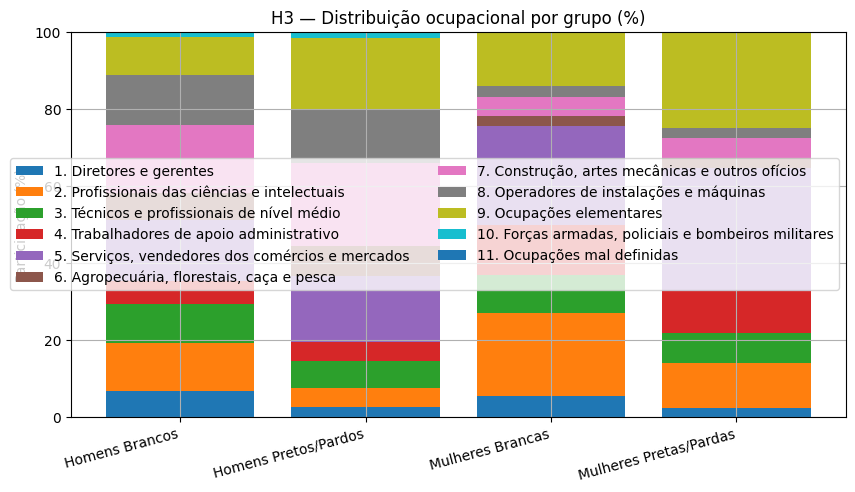

In [20]:
plot_stacked_bar(
    piv_h3,
    title="H3 — Distribuição ocupacional por grupo (%)",
    show=SHOW_PLOTS
)

🎓 Distribuição ocupacional (%) entre altamente escolarizados

In [21]:
df_high = df[
    df["escolaridade_desc"].isin([
        "Superior completo",
        "Pós-graduação (ou equivalente)"
    ])
]

tab_h3_high = (
    df_high
    .groupby(["grupo_h1", "ocup_h3"], observed=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="peso")
)

total_h3_high = (
    tab_h3_high
    .groupby("grupo_h1")["peso"]
    .sum()
    .reset_index(name="total")
)

tab_h3_high = tab_h3_high.merge(total_h3_high, on="grupo_h1")
tab_h3_high["pct"] = (tab_h3_high["peso"] / tab_h3_high["total"]) * 100

piv_h3_high = tab_h3_high.pivot(index="grupo_h1", columns="ocup_h3", values="pct").fillna(0)

piv_h3_high = piv_h3_high.reindex(GROUP_ORDER)
piv_h3_high = piv_h3_high[[c for c in H3_ORDER if c in piv_h3_high.columns]]

display(piv_h3_high.round(2))

ocup_h3,1. Diretores e gerentes,2. Profissionais das ciências e intelectuais,3. Técnicos e profissionais de nível médio,4. Trabalhadores de apoio administrativo,"5. Serviços, vendedores dos comércios e mercados","6. Agropecuária, florestais, caça e pesca","7. Construção, artes mecânicas e outros ofícios",8. Operadores de instalações e máquinas,9. Ocupações elementares,"10. Forças armadas, policiais e bombeiros militares",11. Ocupações mal definidas
grupo_h1,,,,,,,,,,,
Homens Brancos,14.62,44.6,14.13,6.42,9.16,1.33,3.73,2.59,1.01,2.39,0.02
Homens Pretos/Pardos,8.73,39.1,15.3,9.22,11.5,0.8,4.55,4.06,1.73,5.0,0.02
Mulheres Brancas,9.35,54.07,10.46,11.88,10.21,0.35,1.69,0.49,1.08,0.42,0.01
Mulheres Pretas/Pardas,5.79,51.75,10.35,14.13,12.64,0.24,1.79,0.59,2.09,0.62,0.02


📊 Gráfico

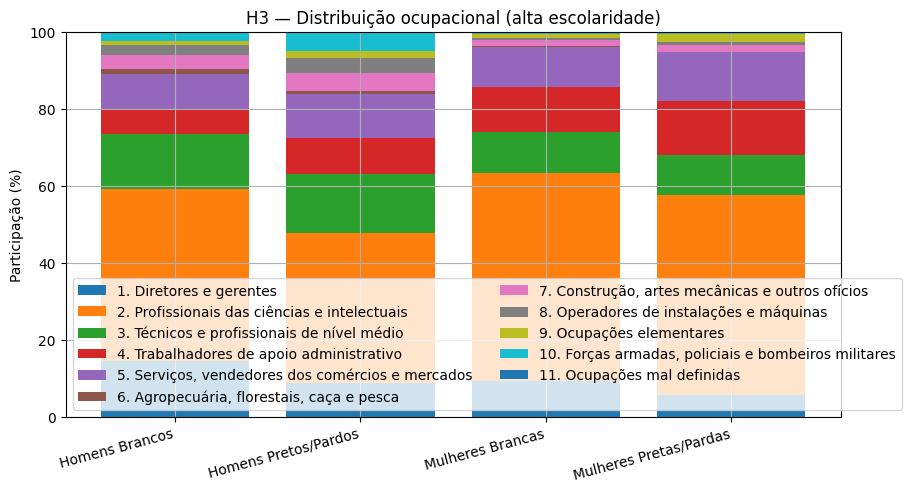

In [22]:
plot_stacked_bar(
    piv_h3_high,
    title="H3 — Distribuição ocupacional (alta escolaridade)",
    show=SHOW_PLOTS
)

## H4 — Formalização

A hipótese H4 testa se o avanço da escolaridade aumenta a formalização do trabalho de forma homogênea ou se ainda há desigualdades importantes entre grupos, mesmo em níveis mais altos de educação.

🔢 Formalização (%) por escolaridade × grupo

In [23]:
tab_h4 = (
    df
    .groupby(["escolaridade_desc", "grupo_h1"], observed=False)[["formal_ampliado", WEIGHT_COL]]
    .apply(lambda g: wmean(g["formal_ampliado"], g[WEIGHT_COL]) * 100)
    .reset_index(name="pct_formal")
)

piv_h4 = tab_h4.pivot(index="escolaridade_desc", columns="grupo_h1", values="pct_formal")

piv_h4 = piv_h4.reindex(SCHOOL_ORDER)
piv_h4 = piv_h4[[c for c in GROUP_ORDER if c in piv_h4.columns]]

display(piv_h4.round(1))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
escolaridade_desc,,,,
Sem instrução/Fundamental incompleto,53.6,39.1,44.6,33.6
Fundamental completo,65.0,52.4,56.4,45.5
Médio incompleto,62.5,51.3,55.9,43.8
Médio completo,75.4,67.6,70.4,60.3
Superior incompleto,73.1,69.7,66.4,61.7
Superior completo,83.8,79.5,81.4,75.0
Pós-graduação (ou equivalente),87.0,84.5,84.7,80.2


📊 Gráfico

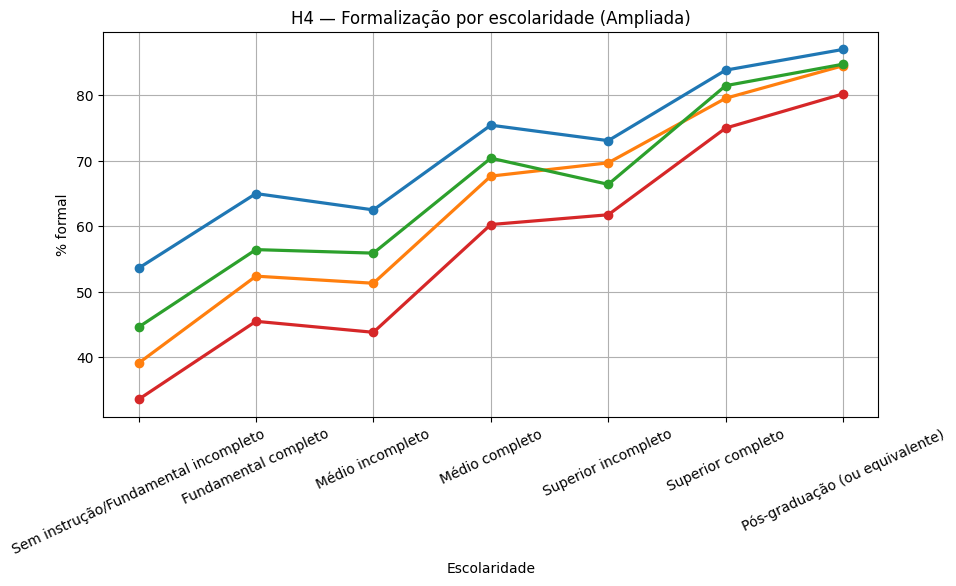

In [59]:
fig, ax = plt.subplots()

x = piv_h4.index.astype(str)

for col in piv_h4.columns:
    styled_line(ax, x, piv_h4[col].values, col)

ax.set_title("H4 — Formalização por escolaridade (Ampliada)")
ax.set_xlabel("Escolaridade")
ax.set_ylabel("% formal")
ax.tick_params(axis="x", rotation=25)

show_or_close(fig, SHOW_PLOTS)

🔢 Formalização (%) por ano × grupo

In [25]:
tab_h4_ano = (
    df
    .groupby(["ano", "grupo_h1"], observed=False)[["formal_ampliado", WEIGHT_COL]]
    .apply(lambda g: wmean(g["formal_ampliado"], g[WEIGHT_COL]) * 100)
    .reset_index(name="pct_formal")
)

piv_h4_ano = tab_h4_ano.pivot(index="ano", columns="grupo_h1", values="pct_formal")
piv_h4_ano = piv_h4_ano[[c for c in GROUP_ORDER if c in piv_h4_ano.columns]]

display(piv_h4_ano.round(1))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,72.8,57.3,70.2,55.5
2016,73.8,57.6,71.8,56.8
2017,72.1,56.9,70.0,55.4
2018,71.6,56.7,69.3,54.7
2019,70.8,56.5,68.9,54.5
2020,72.6,57.4,70.7,56.5
2021,70.7,56.0,69.3,56.1
2022,70.9,56.8,69.0,55.3
2023,70.8,57.6,69.1,56.3


📊 Gráfico

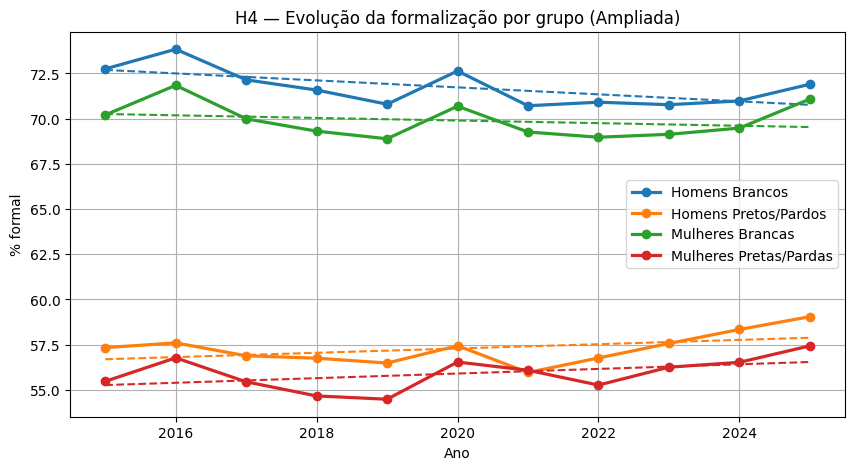

In [60]:
plot_series_por_grupo_com_tendencia(
    piv_h4_ano,
    title="H4 — Evolução da formalização por grupo (Ampliada)",
    y_label="% formal",
    show=SHOW_PLOTS
)

🔢 Formalização (%) por escolaridade × grupo

In [27]:
cat = df["categoria_trabalho"].astype(str).str.zfill(2)

df["formal_carteira"] = np.nan

df.loc[cat.isin(["01", "03", "05", "07"]), "formal_carteira"] = 1.0
df.loc[cat.isin(["02", "04", "06"]), "formal_carteira"] = 0.0

df["formal_carteira_escopo"] = np.where(
    cat.isin(["01", "02", "03", "04", "05", "06", "07"]),
    1.0,
    np.nan
)

df_h4b = df[df["formal_carteira_escopo"].eq(1)]

tab_h4b = (
    df_h4b
    .groupby(["escolaridade_desc", "grupo_h1"], observed=False)[["formal_carteira", WEIGHT_COL]]
    .apply(lambda g: wmean(g["formal_carteira"], g[WEIGHT_COL]) * 100)
    .reset_index(name="pct_formal")
)

piv_h4b = tab_h4b.pivot(index="escolaridade_desc", columns="grupo_h1", values="pct_formal")

piv_h4b = piv_h4b.reindex(SCHOOL_ORDER)
piv_h4b = piv_h4b[[c for c in GROUP_ORDER if c in piv_h4b.columns]]

display(piv_h4b.round(1))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
escolaridade_desc,,,,
Sem instrução/Fundamental incompleto,66.0,54.3,51.4,42.3
Fundamental completo,76.0,66.9,63.7,54.3
Médio incompleto,72.3,63.6,63.9,53.2
Médio completo,83.9,79.2,77.8,69.3
Superior incompleto,76.0,75.4,69.4,67.0
Superior completo,86.2,84.0,84.5,78.9
Pós-graduação (ou equivalente),87.1,86.7,86.9,82.7


📊 Gráfico

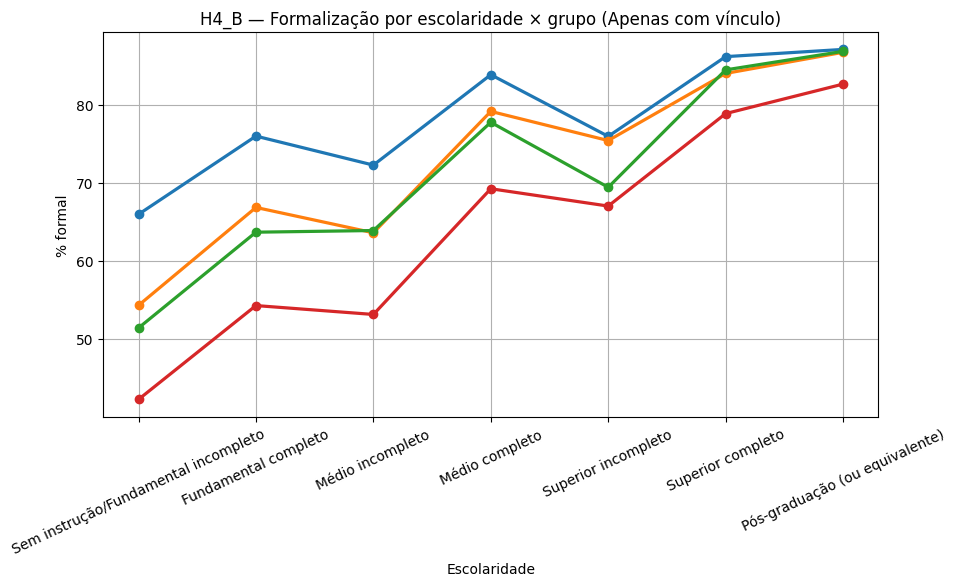

In [61]:
fig, ax = plt.subplots()

x = piv_h4b.index.astype(str)

for col in piv_h4b.columns:
    styled_line(ax, x, piv_h4b[col].values, col)

ax.set_title("H4_B — Formalização por escolaridade × grupo (Apenas com vínculo)")
ax.set_xlabel("Escolaridade")
ax.set_ylabel("% formal")
ax.tick_params(axis="x", rotation=25)

show_or_close(fig, SHOW_PLOTS)

🔢 Formalização (%) por ano × grupo

In [29]:
tab_h4b_ano = (
    df_h4b
    .groupby(["ano", "grupo_h1"], observed=False)[["formal_carteira", WEIGHT_COL]]
    .apply(lambda g: wmean(g["formal_carteira"], g[WEIGHT_COL]) * 100)
    .reset_index(name="pct_formal")
)

piv_h4b_ano = tab_h4b_ano.pivot(index="ano", columns="grupo_h1", values="pct_formal")
piv_h4b_ano = piv_h4b_ano[[c for c in GROUP_ORDER if c in piv_h4b_ano.columns]]

display(piv_h4b_ano.round(1))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,83.2,74.2,78.2,66.3
2016,82.2,72.6,78.1,66.3
2017,80.5,71.2,76.5,64.8
2018,79.6,70.4,75.5,63.8
2019,79.0,70.0,75.0,63.7
2020,80.7,71.4,77.0,66.1
2021,79.4,69.5,75.9,65.4
2022,78.5,69.2,74.3,62.9
2023,78.3,69.4,73.5,63.6


📊 Gráfico

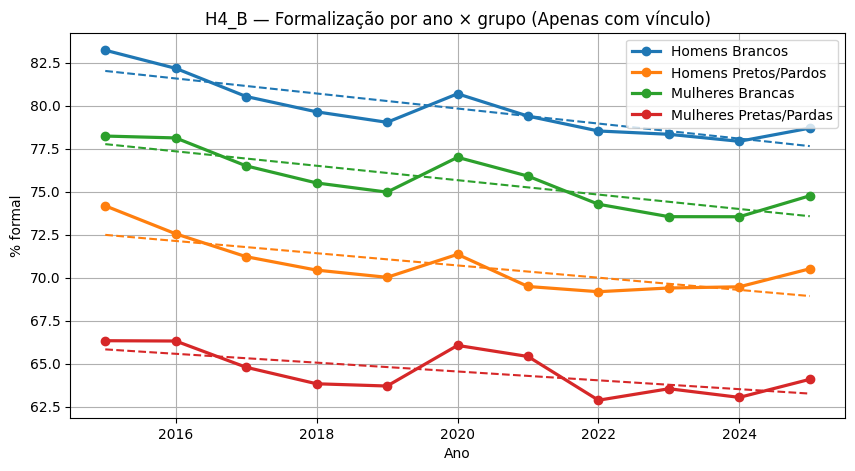

In [62]:
plot_series_por_grupo_com_tendencia(
    piv_h4b_ano,
    title="H4_B — Formalização por ano × grupo (Apenas com vínculo)",
    y_label="% formal",
    show=SHOW_PLOTS
)

## H5 — Estrutura ocupacional + renda

Nesta etapa, o interesse é verificar se a desigualdade pode ser explicada apenas pela distribuição ocupacional ou se continua aparecendo mesmo dentro das mesmas posições de ocupação.

🔢 Distribuição ponderada (%) por posição na ocupação

In [31]:
POS_ORDER = [
    "Privado com carteira",
    "Privado sem carteira",
    "Doméstico com carteira",
    "Doméstico sem carteira",
    "Público com carteira",
    "Público sem carteira",
    "Militar/estatutário",
    "Empregador",
    "Conta própria",
    "Auxiliar familiar",
]

tab_h5 = (
    df
    .groupby(["grupo_h1", "posicao_ocupacao_desc"], observed=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="peso")
)

total_h5 = (
    tab_h5
    .groupby("grupo_h1")["peso"]
    .sum()
    .reset_index(name="total")
)

tab_h5 = tab_h5.merge(total_h5, on="grupo_h1")
tab_h5["pct"] = (tab_h5["peso"] / tab_h5["total"]) * 100

piv_h5 = tab_h5.pivot(index="grupo_h1", columns="posicao_ocupacao_desc", values="pct").fillna(0)

piv_h5 = piv_h5.reindex(GROUP_ORDER)
piv_h5 = piv_h5[[c for c in POS_ORDER if c in piv_h5.columns]]

display(piv_h5.round(2))

posicao_ocupacao_desc,Privado com carteira,Privado sem carteira,Doméstico com carteira,Doméstico sem carteira,Público com carteira,Público sem carteira,Militar/estatutário,Empregador,Conta própria,Auxiliar familiar
grupo_h1,,,,,,,,,,
Homens Brancos,42.41,11.14,0.28,0.35,1.31,1.44,7.29,7.39,27.59,0.8
Homens Pretos/Pardos,39.45,16.8,0.41,0.58,0.89,2.04,6.03,3.43,29.37,1.0
Mulheres Brancas,39.08,8.27,2.73,6.47,2.1,3.24,11.99,4.28,19.36,2.49
Mulheres Pretas/Pardas,32.96,9.76,4.41,12.33,1.5,4.69,9.74,1.81,19.85,2.93


📊 Gráfico (posição na ocupação)

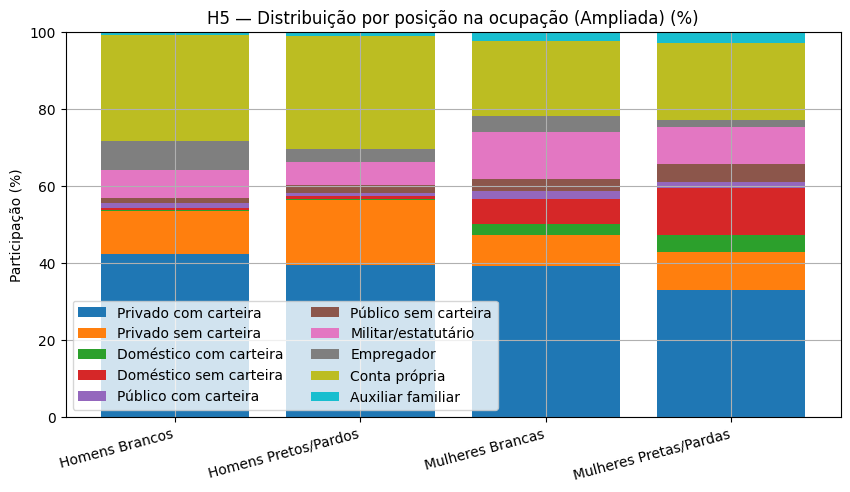

In [63]:
plot_stacked_bar(
    piv_h5,
    title="H5 — Distribuição por posição na ocupação (Ampliada) (%)",
    show=SHOW_PLOTS
)

🔢 Renda média ponderada (R$) por posição na ocupação × grupo

In [33]:
tab_h5_renda = (
    df_plot
    .groupby(["posicao_ocupacao_desc", "grupo_h1"], observed=False)[[VALUE_COL, WEIGHT_COL]]
    .apply(lambda g: wmean(g[VALUE_COL], g[WEIGHT_COL]))
    .reset_index(name="renda_media")
)

piv_h5_renda = tab_h5_renda.pivot(index="posicao_ocupacao_desc", columns="grupo_h1", values="renda_media")

piv_h5_renda = piv_h5_renda[[c for c in GROUP_ORDER if c in piv_h5_renda.columns]]

piv_h5_renda = piv_h5_renda.loc[
    [c for c in POS_ORDER if c in piv_h5_renda.index]
]

piv_h5_renda = piv_h5_renda.dropna(how="all")

display(piv_h5_renda.round(2))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
posicao_ocupacao_desc,,,,
Privado com carteira,3792.44,2609.41,3109.33,2185.04
Privado sem carteira,2807.92,1592.96,2554.92,1479.64
Doméstico com carteira,2151.14,1892.72,1777.30,1696.45
Doméstico sem carteira,1498.37,1288.59,1193.95,980.61
Público com carteira,6626.52,4274.64,4449.27,3043.69
Público sem carteira,3687.11,2568.51,2788.75,2178.78
Militar/estatutário,7178.16,5361.23,5373.42,4009.67
Empregador,7744.66,5399.99,6472.89,4687.96
Conta própria,3331.64,2041.89,2744.70,1497.29


📊 Heatmap

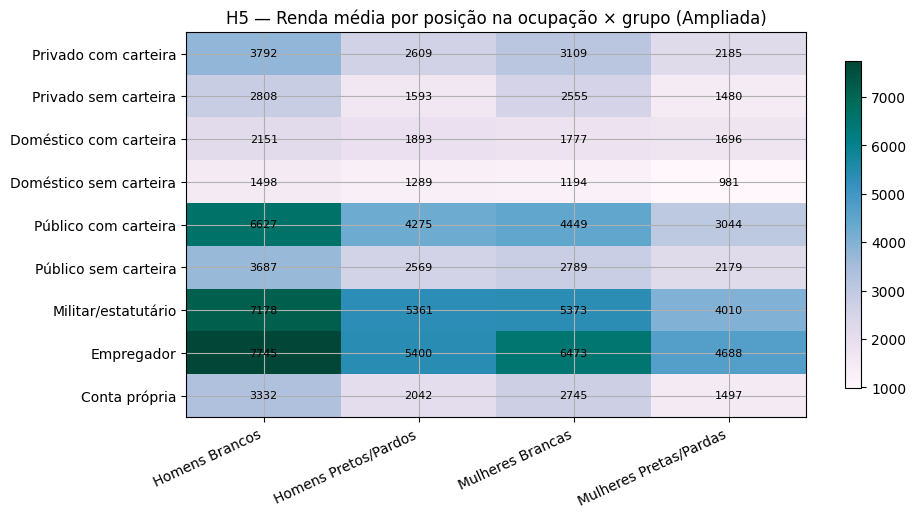

In [64]:
plot_heatmap_like(
    piv_h5_renda,
    title="H5 — Renda média por posição na ocupação × grupo (Ampliada)",
    cmap="PuBuGn",
    fmt=".0f",
    show=SHOW_PLOTS
)

🔢 Informalidade (%) dentro de Conta própria

In [35]:
df_cp = df[df["posicao_ocupacao_desc"] == "Conta própria"]

tab_inf = (
    df_cp
    .groupby("grupo_h1", observed=False)[["formal_ampliado", WEIGHT_COL]]
    .apply(lambda g: wmean(g["formal_ampliado"], g[WEIGHT_COL]) * 100)
    .reset_index(name="pct_formal")
)

tab_inf["pct_informal"] = 100 - tab_inf["pct_formal"]

tab_inf = tab_inf.set_index("grupo_h1").reindex(GROUP_ORDER)

display(tab_inf["pct_informal"].round(2))

,pct_informal
grupo_h1,
Homens Brancos,50.32
Homens Pretos/Pardos,73.10
Mulheres Brancas,48.67
Mulheres Pretas/Pardas,71.07


🔢 Distribuição ponderada (%) por posição na ocupação

In [36]:
tab_h5b_dist = (
    df
    .groupby(["grupo_h1", "posicao_ocupacao_desc"], observed=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="peso")
)

total_h5b = (
    tab_h5b_dist
    .groupby("grupo_h1")[WEIGHT_COL]
    .sum()
    .reset_index(name="total")
)

tab_h5b_dist = tab_h5b_dist.merge(total_h5b, on="grupo_h1")
tab_h5b_dist["pct"] = (tab_h5b_dist["peso"] / tab_h5b_dist["total"]) * 100

piv_h5b_dist = tab_h5b_dist.pivot(index="grupo_h1", columns="posicao_ocupacao_desc", values="pct").fillna(0)

piv_h5b_dist = piv_h5b_dist.reindex(GROUP_ORDER)
piv_h5b_dist = piv_h5b_dist[[c for c in POS_ORDER if c in piv_h5b_dist.columns]]

display(piv_h5b_dist.round(2))

posicao_ocupacao_desc,Privado com carteira,Privado sem carteira,Doméstico com carteira,Doméstico sem carteira,Público com carteira,Público sem carteira,Militar/estatutário,Empregador,Conta própria,Auxiliar familiar
grupo_h1,,,,,,,,,,
Homens Brancos,42.41,11.14,0.28,0.35,1.31,1.44,7.29,7.39,27.59,0.8
Homens Pretos/Pardos,39.45,16.8,0.41,0.58,0.89,2.04,6.03,3.43,29.37,1.0
Mulheres Brancas,39.08,8.27,2.73,6.47,2.1,3.24,11.99,4.28,19.36,2.49
Mulheres Pretas/Pardas,32.96,9.76,4.41,12.33,1.5,4.69,9.74,1.81,19.85,2.93


📊 Gráfico — distribuição

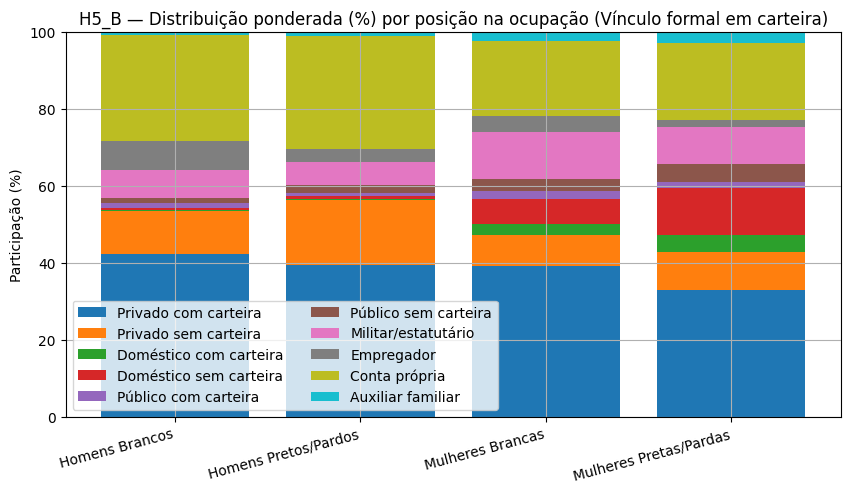

In [65]:
plot_stacked_bar(
    piv_h5b_dist,
    title="H5_B — Distribuição ponderada (%) por posição na ocupação (Vínculo formal em carteira)",
    show=SHOW_PLOTS
)

🔢 Renda média ponderada (R$) por posição na ocupação × grupo

In [38]:
tab_h5_renda = (
    df_plot
    .groupby(["posicao_ocupacao_desc", "grupo_h1"], observed=False)[[VALUE_COL, WEIGHT_COL]]
    .apply(lambda g: wmean(g[VALUE_COL], g[WEIGHT_COL]))
    .reset_index(name="renda_media")
)

piv_h5_renda = tab_h5_renda.pivot(index="posicao_ocupacao_desc", columns="grupo_h1", values="renda_media")

piv_h5_renda = piv_h5_renda[[c for c in GROUP_ORDER if c in piv_h5_renda.columns]]

ordered_idx = [c for c in POS_ORDER if c in piv_h5_renda.index]
piv_h5_renda = piv_h5_renda.loc[ordered_idx]

piv_h5_renda = piv_h5_renda.dropna(how="all")

display(piv_h5_renda.round(2))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
posicao_ocupacao_desc,,,,
Privado com carteira,3792.44,2609.41,3109.33,2185.04
Privado sem carteira,2807.92,1592.96,2554.92,1479.64
Doméstico com carteira,2151.14,1892.72,1777.30,1696.45
Doméstico sem carteira,1498.37,1288.59,1193.95,980.61
Público com carteira,6626.52,4274.64,4449.27,3043.69
Público sem carteira,3687.11,2568.51,2788.75,2178.78
Militar/estatutário,7178.16,5361.23,5373.42,4009.67
Empregador,7744.66,5399.99,6472.89,4687.96
Conta própria,3331.64,2041.89,2744.70,1497.29


📊 Heatmap

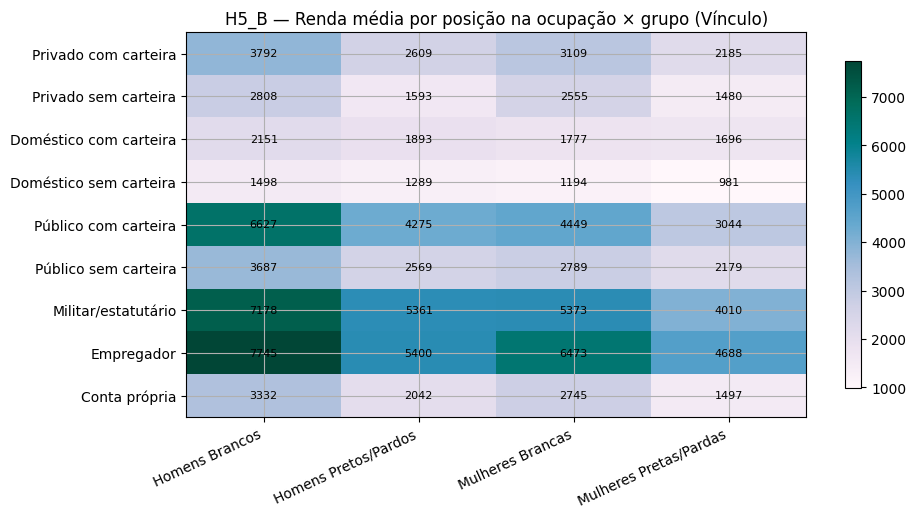

In [66]:
plot_heatmap_like(
    piv_h5_renda,
    title="H5_B — Renda média por posição na ocupação × grupo (Vínculo)",
    cmap="PuBuGn",
    fmt=".0f",
    show=SHOW_PLOTS
)

🔢 Informalidade (%) no escopo assalariado elegível à carteira

In [40]:
df_h5b_inf = df[
    df["posicao_ocupacao_desc"].isin([
        "Privado com carteira",
        "Privado sem carteira",
        "Doméstico com carteira",
        "Doméstico sem carteira",
        "Público com carteira",
        "Público sem carteira",
        "Militar/estatutário"
    ])
]

tab_h5b_inf = (
    df_h5b_inf
    .groupby("grupo_h1", observed=False)[["formal_carteira", WEIGHT_COL]]
    .apply(lambda g: wmean(g["formal_carteira"], g[WEIGHT_COL]) * 100)
    .reset_index(name="pct_formal")
)

tab_h5b_inf["pct_informal"] = 100 - tab_h5b_inf["pct_formal"]

tab_h5b_inf = tab_h5b_inf.set_index("grupo_h1").reindex(GROUP_ORDER)

display(tab_h5b_inf["pct_informal"].round(2))

,pct_informal
grupo_h1,
Homens Brancos,20.14
Homens Pretos/Pardos,29.34
Mulheres Brancas,24.33
Mulheres Pretas/Pardas,35.52


## H6 — Jovens no mercado de trabalho

H6 investiga se, entre jovens, as desigualdades históricas continuam presentes. A leitura é importante porque sinaliza a persistência — ou eventual redução — de assimetrias nas gerações mais recentes.

🔢 Renda média ponderada (R$) entre jovens por escolaridade × grupo

In [41]:
df_young = df_plot[df_plot["idade"].between(18, 29)]
tab_h6 = (
    df_young
    .groupby(["escolaridade_desc", "grupo_h1"], observed=False)[[VALUE_COL, WEIGHT_COL]]
    .apply(lambda g: wmean(g[VALUE_COL], g[WEIGHT_COL]))
    .reset_index(name="renda_media")
)

piv_h6 = tab_h6.pivot(index="escolaridade_desc", columns="grupo_h1", values="renda_media")

piv_h6 = piv_h6.reindex(SCHOOL_ORDER)
piv_h6 = piv_h6[[c for c in GROUP_ORDER if c in piv_h6.columns]]

display(piv_h6.round(2))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
escolaridade_desc,,,,
Sem instrução/Fundamental incompleto,1681.30,1384.88,1322.56,1028.65
Fundamental completo,1977.91,1654.09,1512.69,1227.61
Médio incompleto,1942.38,1654.40,1495.56,1225.05
Médio completo,2262.40,1909.04,1779.31,1503.19
Superior incompleto,2598.81,2310.42,1959.21,1725.27
Superior completo,4691.79,3701.82,3545.03,2784.64
Pós-graduação (ou equivalente),6291.14,4974.69,4890.04,3761.82


📊 Heatmap

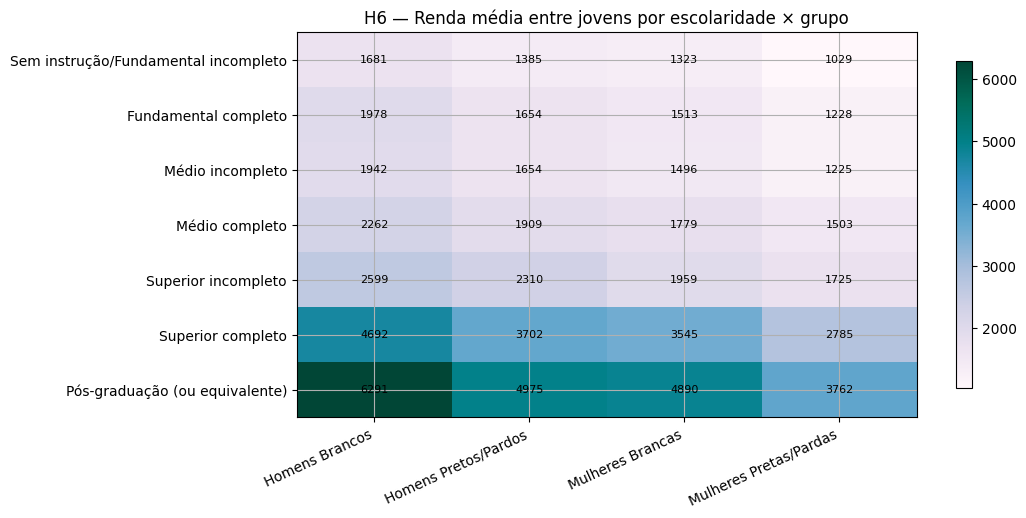

In [42]:
plot_heatmap_like(
    piv_h6,
    title="H6 — Renda média entre jovens por escolaridade × grupo",
    cmap="PuBuGn",
    fmt=".0f",
    show=SHOW_PLOTS
)

🔢 Formalização Jovens

In [43]:
tab_h6_formal = (
    df_young
    .groupby("grupo_h1", observed=False)[["formal_ampliado", WEIGHT_COL]]
    .apply(lambda g: wmean(g["formal_ampliado"], g[WEIGHT_COL]) * 100)
    .reset_index(name="pct_formal")
)

tab_h6_formal = tab_h6_formal.set_index("grupo_h1").reindex(GROUP_ORDER)

display(tab_h6_formal.round(2))

,pct_formal
grupo_h1,
Homens Brancos,66.49
Homens Pretos/Pardos,53.76
Mulheres Brancas,66.89
Mulheres Pretas/Pardas,54.26


🔢 Evolução da renda

In [44]:
tab_h6_ano = (
    df_young
    .groupby(["ano", "grupo_h1"], observed=False)[[VALUE_COL, WEIGHT_COL]]
    .apply(lambda g: wmean(g[VALUE_COL], g[WEIGHT_COL]))
    .reset_index(name="renda_media")
)

piv_h6_ano = tab_h6_ano.pivot(index="ano", columns="grupo_h1", values="renda_media")
piv_h6_ano = piv_h6_ano[[c for c in GROUP_ORDER if c in piv_h6_ano.columns]]

display(piv_h6_ano.round(2))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,2771.51,1940.49,2280.87,1615.08
2016,2646.81,1855.01,2315.53,1593.63
2017,2610.78,1890.46,2276.49,1619.27
2018,2544.53,1860.89,2266.68,1616.20
2019,2541.15,1855.65,2258.22,1589.41
2020,2587.25,1888.15,2354.64,1638.93
2021,2488.43,1841.02,2203.38,1583.66
2022,2634.27,1879.84,2267.32,1647.27
2023,2722.02,1991.83,2367.13,1748.26


📈 Gráfico evolução da renda (jovens)

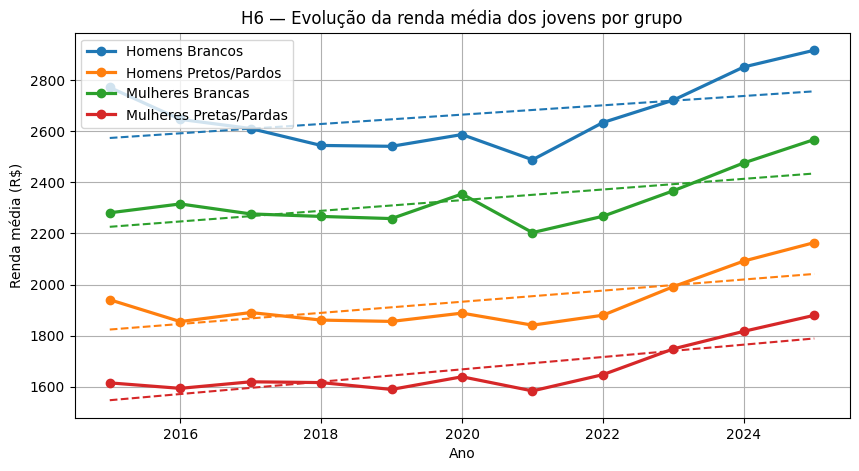

In [45]:
plot_series_por_grupo_com_tendencia(
    piv_h6_ano,
    title="H6 — Evolução da renda média dos jovens por grupo",
    y_label="Renda média (R$)",
    show=SHOW_PLOTS
)

## H7 — Cargos de liderança

A hipótese H7 observa o topo da estrutura ocupacional: diretoria, gerência e cargos de liderança. O objetivo é verificar se a presença nesses espaços é proporcional à distribuição da população ocupada ou se há concentração em grupos específicos.

🔢 Nº estimado de cadeiras por ano × grupo

In [46]:
df_dir = df[
    df["cbo_detalhe_label"].str.contains("Diretor", case=False, na=False)
]
tab_h7a = (
    df_dir
    .groupby(["ano", "grupo_h1"], observed=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="cadeiras")
)

piv_h7a = tab_h7a.pivot(index="ano", columns="grupo_h1", values="cadeiras")
piv_h7a = piv_h7a.reindex(columns=[c for c in GROUP_ORDER if c in piv_h7a.columns]).fillna(0)

display(piv_h7a.round(0))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,471990.0,146497.0,136006.0,41209.0
2016,354700.0,90987.0,138506.0,26140.0
2017,328982.0,104459.0,115909.0,34430.0
2018,346667.0,130064.0,131744.0,38471.0
2019,327593.0,123316.0,134028.0,38950.0
2020,333871.0,69573.0,76947.0,25374.0
2021,293255.0,97029.0,110585.0,18986.0
2022,281952.0,107506.0,101269.0,45224.0
2023,311943.0,106961.0,98647.0,32584.0


📊 Gráfico

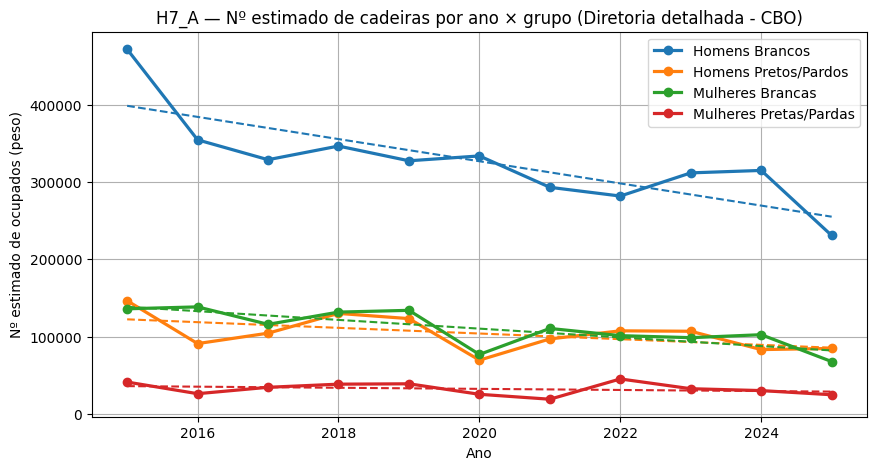

In [47]:
plot_series_por_grupo_com_tendencia(
    piv_h7a,
    title="H7_A — Nº estimado de cadeiras por ano × grupo (Diretoria detalhada - CBO)",
    y_label="Nº estimado de ocupados (peso)",
    show=SHOW_PLOTS
)

🔢 Total acumulado de cadeiras no período

In [48]:
display(piv_h7a.sum().round(0))

,0
grupo_h1,
Homens Brancos,3596961.0
Homens Pretos/Pardos,1144342.0
Mulheres Brancas,1213870.0
Mulheres Pretas/Pardas,356311.0


📊 Gráfico

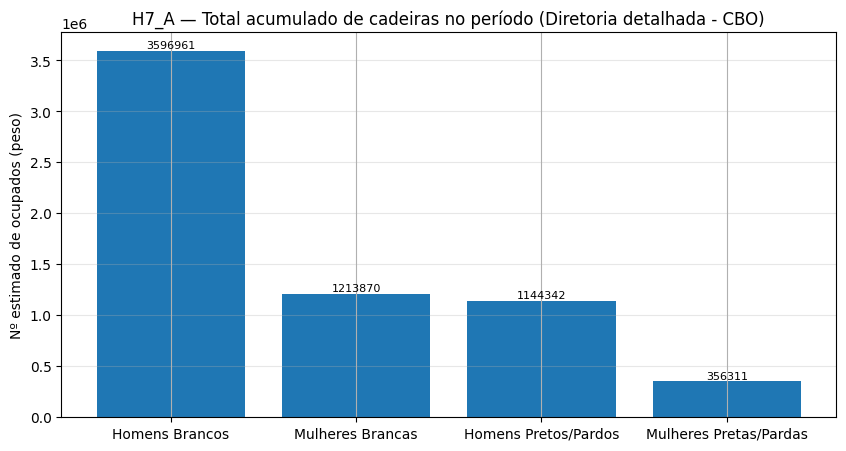

In [67]:
s = piv_h7a.sum()

order = [
    "Homens Brancos",
    "Mulheres Brancas",
    "Homens Pretos/Pardos",
    "Mulheres Pretas/Pardas"
]

s = s.loc[[c for c in order if c in s.index]]

plot_bar_rank(
    s,
    title="H7_A — Total acumulado de cadeiras no período (Diretoria detalhada - CBO)",
    ylabel="Nº estimado de ocupados (peso)",
    fmt="{:.0f}",
    show=SHOW_PLOTS
)

🔢 Participação percentual por grupo dentro do total anual de cadeiras

In [50]:
pct_h7a = piv_h7a.div(piv_h7a.sum(axis=1), axis=0) * 100
display(pct_h7a.round(2))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,59.32,18.41,17.09,5.18
2016,58.12,14.91,22.69,4.28
2017,56.35,17.89,19.85,5.9
2018,53.59,20.1,20.36,5.95
2019,52.51,19.77,21.48,6.24
2020,66.01,13.76,15.21,5.02
2021,56.41,18.66,21.27,3.65
2022,52.61,20.06,18.9,8.44
2023,56.7,19.44,17.93,5.92


📊 Gráfico

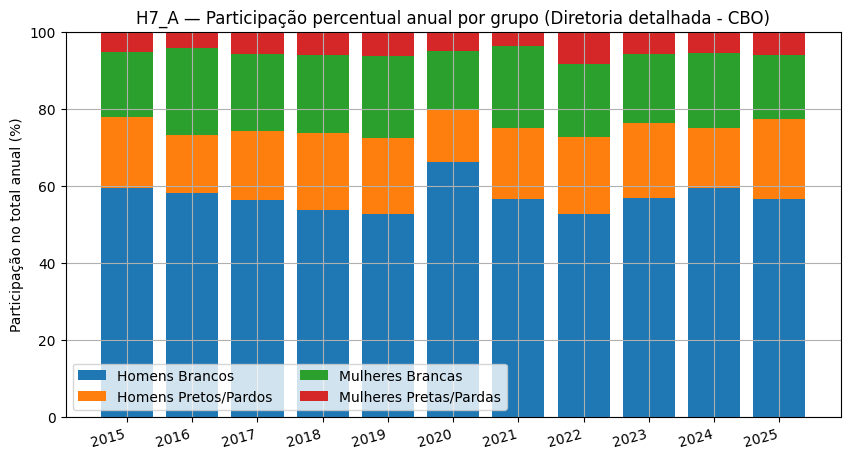

In [51]:
plot_stacked_bar(
    pct_h7a,
    title="H7_A — Participação percentual anual por grupo (Diretoria detalhada - CBO)",
    ylabel="Participação no total anual (%)",
    show=SHOW_PLOTS
)

🔢 Razão de representação relativa (cadeiras / ocupados)

In [52]:
base_total = (
    df
    .groupby(["ano", "grupo_h1"], observed=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="total")
)

piv_total = base_total.pivot(index="ano", columns="grupo_h1", values="total")
piv_total = piv_total.reindex(columns=[c for c in GROUP_ORDER if c in piv_total.columns])

share_lider = piv_h7a.div(piv_h7a.sum(axis=1), axis=0)
share_total = piv_total.div(piv_total.sum(axis=1), axis=0)

ratio_h7a = share_lider / share_total

display(ratio_h7a.round(3))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,2.277,0.586,0.808,0.242
2016,2.232,0.474,1.086,0.198
2017,2.213,0.566,0.962,0.264
2018,2.151,0.629,1.0,0.261
2019,2.141,0.614,1.057,0.272
2020,2.589,0.425,0.748,0.23
2021,2.227,0.574,1.055,0.166
2022,2.139,0.621,0.935,0.368
2023,2.328,0.6,0.895,0.255


📊 Heatmap

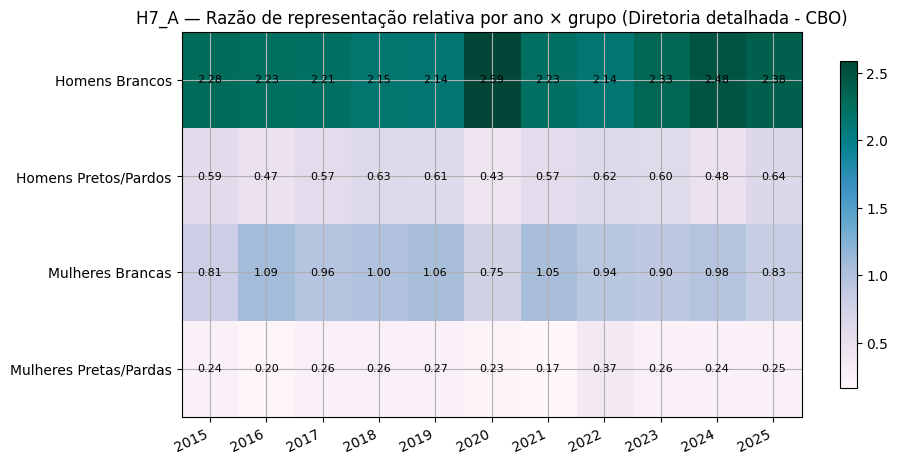

In [53]:
plot_heatmap_like(
    ratio_h7a.T,
    title="H7_A — Razão de representação relativa por ano × grupo (Diretoria detalhada - CBO)",
    cmap="PuBuGn",
    fmt=".2f",
    show=SHOW_PLOTS
)

🔢 Nº estimado de cadeiras por ano × grupo

In [54]:
df_ger = df[
    df["cbo_detalhe_label"].str.contains("Gerente", case=False, na=False)
]
tab_h7b = (
    df_ger
    .groupby(["ano", "grupo_h1"], observed=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="cadeiras")
)

piv_h7b = tab_h7b.pivot(index="ano", columns="grupo_h1", values="cadeiras")
piv_h7b = piv_h7b.reindex(columns=[c for c in GROUP_ORDER if c in piv_h7b.columns]).fillna(0)

display(piv_h7b.round(0))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,2096145.0,1144713.0,1506782.0,753289.0
2016,2252264.0,1166470.0,1668940.0,805464.0
2017,2132329.0,1069355.0,1616801.0,800109.0
2018,2105227.0,1098101.0,1470872.0,735173.0
2019,1976312.0,1070534.0,1321335.0,741721.0
2020,1748973.0,911695.0,1215726.0,555971.0
2021,1784839.0,864979.0,1390020.0,618879.0
2022,1816139.0,1074328.0,1320880.0,730325.0
2023,1899869.0,1016854.0,1329609.0,736879.0


📊 Gráfico

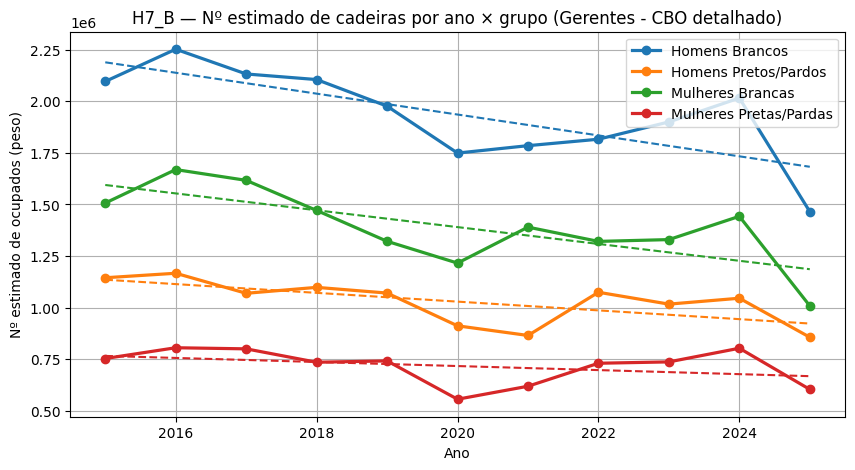

In [55]:
plot_series_por_grupo_com_tendencia(
    piv_h7b,
    title="H7_B — Nº estimado de cadeiras por ano × grupo (Gerentes - CBO detalhado)",
    y_label="Nº estimado de ocupados (peso)",
    show=SHOW_PLOTS
)

🔢 Total acumulado de cadeiras no período

In [56]:
display(piv_h7b.sum().round(0))

,0
grupo_h1,
Homens Brancos,21292850.0
Homens Pretos/Pardos,11318883.0
Mulheres Brancas,15291897.0
Mulheres Pretas/Pardas,7884544.0


📊 Gráfico

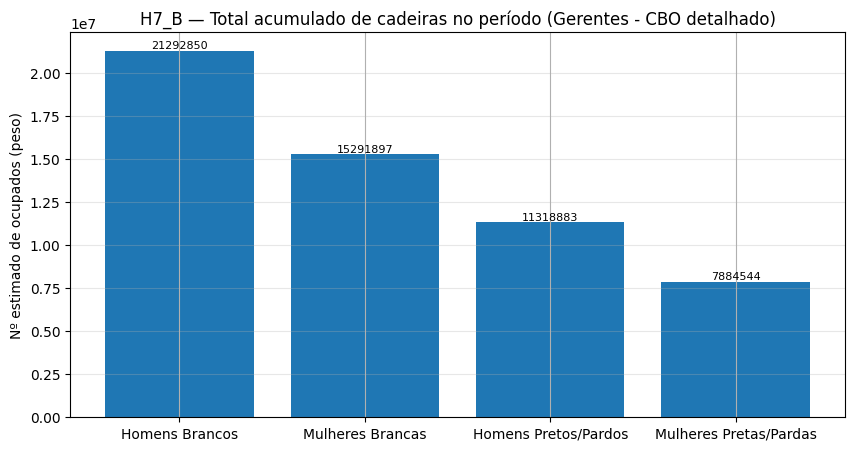

In [68]:
s = piv_h7b.sum()

order = [
    "Homens Brancos",
    "Mulheres Brancas",
    "Homens Pretos/Pardos",
    "Mulheres Pretas/Pardas"
]

s = s.loc[[c for c in order if c in s.index]]

plot_bar_rank(
    s,
    title="H7_B — Total acumulado de cadeiras no período (Gerentes - CBO detalhado)",
    ylabel="Nº estimado de ocupados (peso)",
    fmt="{:.0f}",
    show=SHOW_PLOTS
)

🔢 Participação percentual por grupo dentro do total anual de cadeiras

In [73]:
pct_h7b = piv_h7b.div(piv_h7b.sum(axis=1), axis=0) * 100
display(pct_h7b.round(2))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,38.11,20.81,27.39,13.69
2016,38.22,19.79,28.32,13.67
2017,37.95,19.03,28.78,14.24
2018,38.92,20.3,27.19,13.59
2019,38.68,20.95,25.86,14.52
2020,39.46,20.57,27.43,12.54
2021,38.31,18.57,29.84,13.28
2022,36.75,21.74,26.73,14.78
2023,38.13,20.41,26.68,14.79


📊 Gráfico

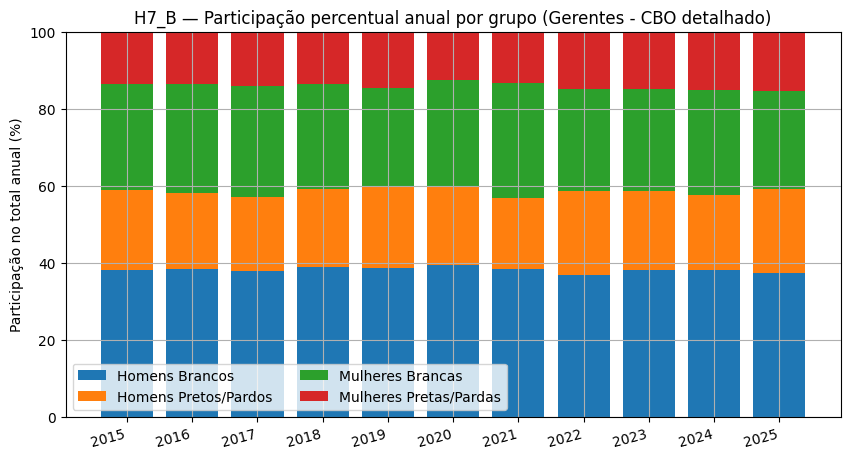

In [78]:
plot_stacked_bar(
    pct_h7b,
    title="H7_B — Participação percentual anual por grupo (Gerentes - CBO detalhado)",
    ylabel="Participação no total anual (%)",
    show=SHOW_PLOTS
)

🔢 Razão de representação relativa (cadeiras / ocupados)

In [79]:
share_lider_b = piv_h7b.div(piv_h7b.sum(axis=1), axis=0)
ratio_h7b = share_lider_b / share_total

display(ratio_h7b.round(3))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,1.463,0.662,1.295,0.64
2016,1.468,0.629,1.356,0.632
2017,1.49,0.602,1.395,0.638
2018,1.562,0.635,1.335,0.597
2019,1.577,0.65,1.272,0.633
2020,1.548,0.636,1.349,0.575
2021,1.513,0.571,1.479,0.604
2022,1.494,0.673,1.323,0.645
2023,1.565,0.63,1.332,0.637


📊 Heatmap

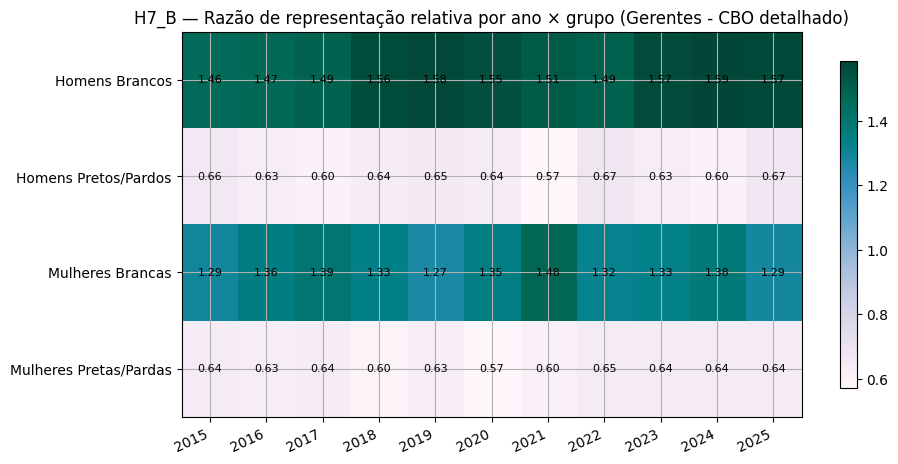

In [80]:
plot_heatmap_like(
    ratio_h7b.T,
    title="H7_B — Razão de representação relativa por ano × grupo (Gerentes - CBO detalhado)",
    cmap="PuBuGn",
    fmt=".2f",
    show=SHOW_PLOTS
)

🔢 Nº estimado de cadeiras por ano × grupo

In [82]:
df_all = df[df["ocup_h3"] == "1. Diretores e gerentes"]
tab_h7c = (
    df_all
    .groupby(["ano", "grupo_h1"], observed=False)[WEIGHT_COL]
    .sum()
    .reset_index(name="cadeiras")
)

piv_h7c = tab_h7c.pivot(index="ano", columns="grupo_h1", values="cadeiras")
piv_h7c = piv_h7c.reindex(columns=[c for c in GROUP_ORDER if c in piv_h7c.columns]).fillna(0)

display(piv_h7c.round(0))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,7228914.0,3452824.0,4811562.0,2008856.0
2016,7362797.0,3308285.0,4831196.0,2071949.0
2017,6967570.0,3179134.0,4570592.0,2113442.0
2018,6253676.0,3101077.0,4081372.0,1985377.0
2019,6508050.0,3084360.0,4105830.0,1988049.0
2020,5586335.0,2580846.0,3464074.0,1387227.0
2021,5065797.0,2560015.0,3383018.0,1528008.0
2022,5058785.0,2799914.0,3446018.0,1721679.0
2023,5073193.0,2578777.0,3392832.0,1768247.0


📊 Gráfico

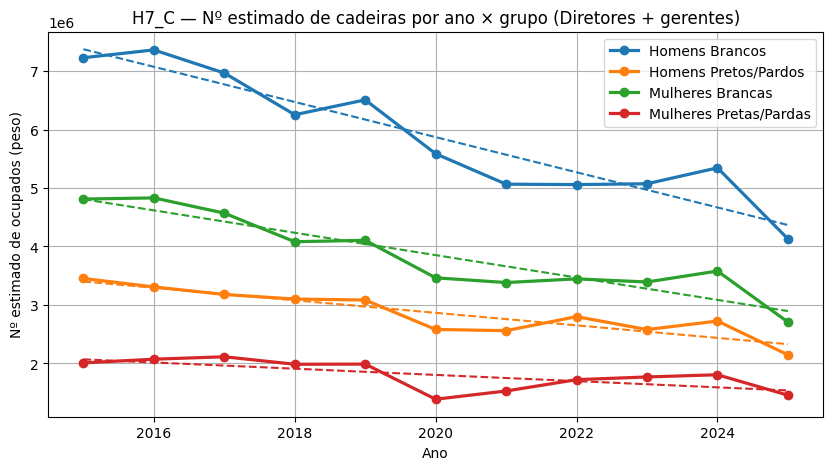

In [83]:
plot_series_por_grupo_com_tendencia(
    piv_h7c,
    title="H7_C — Nº estimado de cadeiras por ano × grupo (Diretores + gerentes)",
    y_label="Nº estimado de ocupados (peso)",
    show=SHOW_PLOTS
)

🔢 Total acumulado de cadeiras no período

In [85]:
display(piv_h7c.sum().round(0))

,0
grupo_h1,
Homens Brancos,64580584.0
Homens Pretos/Pardos,31516268.0
Mulheres Brancas,42373169.0
Mulheres Pretas/Pardas,19835016.0


📊 Gráfico

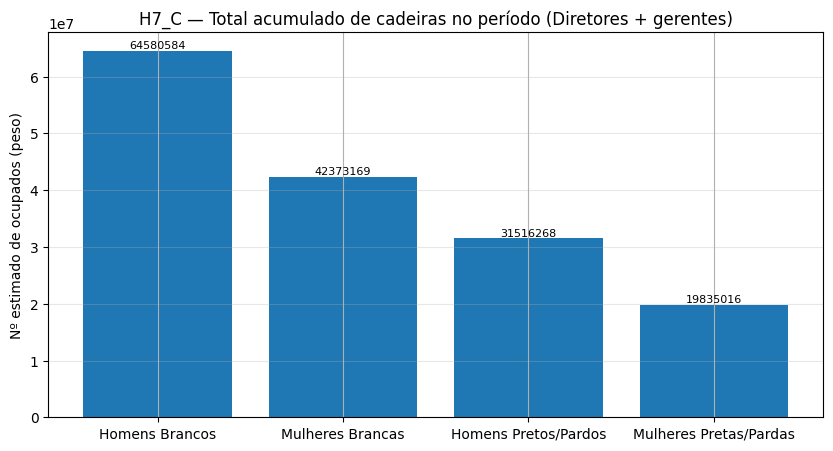

In [87]:
s = piv_h7c.sum()

order = [
    "Homens Brancos",
    "Mulheres Brancas",
    "Homens Pretos/Pardos",
    "Mulheres Pretas/Pardas"
]

s = s.loc[[c for c in order if c in s.index]]

plot_bar_rank(
    s,
    title="H7_C — Total acumulado de cadeiras no período (Diretores + gerentes)",
    ylabel="Nº estimado de ocupados (peso)",
    fmt="{:.0f}",
    show=SHOW_PLOTS
)

🔢 Participação percentual por grupo dentro do total anual de cadeiras

In [88]:
pct_h7c = piv_h7c.div(piv_h7c.sum(axis=1), axis=0) * 100
display(pct_h7c.round(2))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,41.3,19.73,27.49,11.48
2016,41.9,18.82,27.49,11.79
2017,41.4,18.89,27.16,12.56
2018,40.55,20.11,26.47,12.87
2019,41.49,19.66,26.17,12.67
2020,42.91,19.82,26.61,10.66
2021,40.41,20.42,26.98,12.19
2022,38.83,21.49,26.45,13.22
2023,39.59,20.13,26.48,13.8


📊 Gráfico

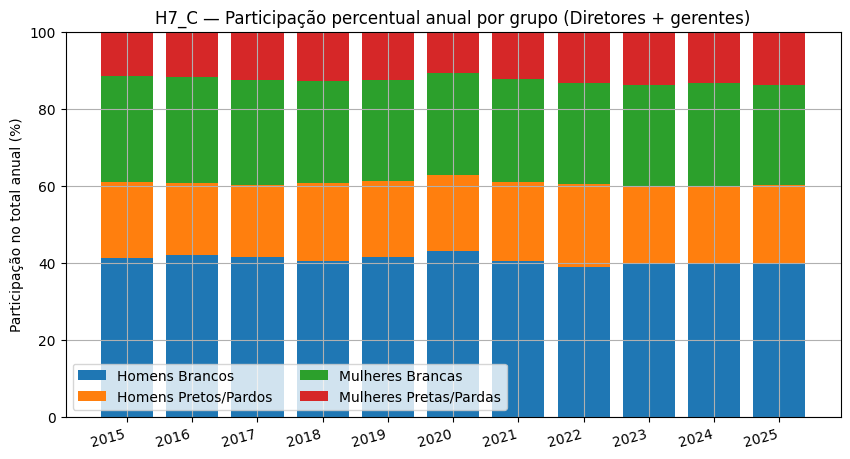

In [89]:
plot_stacked_bar(
    pct_h7c,
    title="H7_C — Participação percentual anual por grupo (Diretores + gerentes)",
    ylabel="Participação no total anual (%)",
    show=SHOW_PLOTS
)

🔢 Razão de representação relativa (cadeiras / ocupados)

In [90]:
share_lider_c = piv_h7c.div(piv_h7c.sum(axis=1), axis=0)
ratio_h7c = share_lider_c / share_total

display(ratio_h7c.round(3))

grupo_h1,Homens Brancos,Homens Pretos/Pardos,Mulheres Brancas,Mulheres Pretas/Pardas
ano,,,,
2015,1.586,0.628,1.3,0.537
2016,1.609,0.598,1.316,0.545
2017,1.626,0.598,1.316,0.563
2018,1.628,0.629,1.299,0.566
2019,1.692,0.61,1.288,0.553
2020,1.683,0.613,1.308,0.488
2021,1.595,0.628,1.338,0.554
2022,1.579,0.666,1.309,0.577
2023,1.625,0.621,1.322,0.594


📊 Heatmap

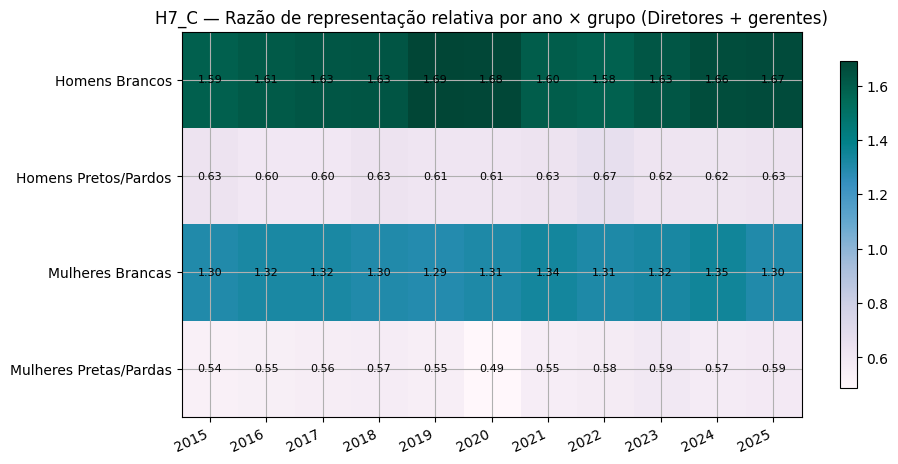

In [91]:
plot_heatmap_like(
    ratio_h7c.T,
    title="H7_C — Razão de representação relativa por ano × grupo (Diretores + gerentes)",
    cmap="PuBuGn",
    fmt=".2f",
    show=SHOW_PLOTS
)

## Leitura acadêmica dos resultados

A seção abaixo foi incluída para dar ao notebook uma feição mais acadêmica e menos operacional. Ela não substitui a interpretação substantiva do TCC, mas organiza um espaço de síntese após a execução dos blocos.

### Pontos de leitura sugeridos

- **H1 e H2:** verificar se a educação melhora os indicadores de todos os grupos, mas sem eliminar hiatos de renda e retorno.
- **H3:** observar possíveis sinais de segregação ocupacional e diferenciação entre grupos nos estratos de maior prestígio.
- **H4:** avaliar se a formalização acompanha o avanço educacional de forma semelhante ou desigual.
- **H5:** distinguir o efeito da posição ocupacional do efeito da desigualdade intrínseca entre grupos dentro da mesma posição.
- **H6:** analisar se os padrões observados entre jovens sugerem reprodução intergeracional das desigualdades.
- **H7:** examinar sobre-representação e sub-representação em cargos de liderança como evidência de assimetria estrutural.

### Este notebook serve como:

registro transparente da lógica analítica utilizada no artigo.

## Encerramento

Este notebook mantém a integridade metodológica do script original `eda.py`, mas reorganiza a análise em uma forma mais apropriada para documentação acadêmica.

Para uso ideal no repositório

**Autoria analítica:** Alberto Nagem